In [11]:
import pandas as pd
import numpy as np
import matplotlib as plt

data_main = pd.read_csv('sources/upload-weeklyshipcrossingsforsixmaritimepassagesofinterest.csv')
data_excel = pd.read_excel(
    'sources/uktradeflowsofcontainerisedproductsthroughglobalmaritimepassages20202024.xlsx',
    sheet_name=['1.Monthly Volumes All (Imports)', '2.Monthly Volumes All (Exports)']
)
data_second = pd.concat(data_excel.values(), ignore_index=True)
data_war = pd.read_csv('sources/GEDEvent_v25_1.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'sources/GEDEvent_v25_1.csv'

In [ ]:
data_main.head()

,Passage,Week of entry,Number of crossings
0,Bab-Al Mandab Strait,03/01/2022,394
1,Bab-Al Mandab Strait,10/01/2022,391
2,Bab-Al Mandab Strait,17/01/2022,386
3,Bab-Al Mandab Strait,24/01/2022,394
4,Bab-Al Mandab Strait,31/01/2022,415


In [ ]:
data_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 695 entries, 0 to 694
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Passage              695 non-null    object
 1   Week of entry        695 non-null    object
 2   Number of crossings  695 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 16.4+ KB


In [ ]:
data_war.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385918 entries, 0 to 385917
Data columns (total 49 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 385918 non-null  int64  
 1   relid              385918 non-null  object 
 2   year               385918 non-null  int64  
 3   active_year        385918 non-null  bool   
 4   code_status        385918 non-null  object 
 5   type_of_violence   385918 non-null  int64  
 6   conflict_dset_id   385918 non-null  int64  
 7   conflict_new_id    385918 non-null  int64  
 8   conflict_name      385918 non-null  object 
 9   dyad_dset_id       385918 non-null  int64  
 10  dyad_new_id        385918 non-null  int64  
 11  dyad_name          385918 non-null  object 
 12  side_a_dset_id     385918 non-null  int64  
 13  side_a_new_id      385918 non-null  int64  
 14  side_a             385918 non-null  object 
 15  side_b_dset_id     385918 non-null  int64  
 16  si

In [ ]:
data_second.head()

,Passage,Direction,TEU,Year,Month
0,Taiwan Strait,import,13625.1,2020,1
1,Taiwan Strait,import,2710.4,2020,2
2,Taiwan Strait,import,11166.5,2020,3
3,Taiwan Strait,import,7766,2020,4
4,Taiwan Strait,import,11118.4,2020,5


In [ ]:
data_second.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Passage    600 non-null    object
 1   Direction  600 non-null    object
 2   TEU        600 non-null    object
 3   Year       600 non-null    int64 
 4   Month      600 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 23.6+ KB


##### Processing data_main

In [ ]:
# Convert "Week of entry" to datetime (day/month/year format)
data_main['Week of entry'] = pd.to_datetime(data_main['Week of entry'], format='%d/%m/%Y')

data_main.head(10)


,Passage,Week of entry,Number of crossings
0,Bab-Al Mandab Strait,2022-01-03,394
1,Bab-Al Mandab Strait,2022-01-10,391
2,Bab-Al Mandab Strait,2022-01-17,386
3,Bab-Al Mandab Strait,2022-01-24,394
4,Bab-Al Mandab Strait,2022-01-31,415
5,Bab-Al Mandab Strait,2022-02-07,443
6,Bab-Al Mandab Strait,2022-02-14,364
7,Bab-Al Mandab Strait,2022-02-21,424
8,Bab-Al Mandab Strait,2022-02-28,394
9,Bab-Al Mandab Strait,2022-03-07,418


In [ ]:
data_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 695 entries, 0 to 694
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Passage              695 non-null    object        
 1   Week of entry        695 non-null    datetime64[ns]
 2   Number of crossings  695 non-null    int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 16.4+ KB


##### Processing data_second

In [ ]:
# 1. Replace "x" in TEU with NaN, then convert to numeric
data_second['TEU'] = pd.to_numeric(data_second['TEU'].replace('x', np.nan))

# 2. Combine Year and Month into a datetime column
data_second['Date'] = pd.to_datetime(data_second[['Year', 'Month']].assign(day=1))

# 3. Group by Passage and Month, summing TEU
data_second = data_second.groupby(
    ['Passage', data_second['Date'].dt.to_period('M')]
).agg({'TEU': 'sum'}).reset_index()

data_second.head(10)

C:\Users\rakad\AppData\Local\Temp\ipykernel_21272\3138249727.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_second['TEU'] = pd.to_numeric(data_second['TEU'].replace('x', np.nan))


,Passage,Date,TEU
0,Cape of Good Hope,2020-01,511.2
1,Cape of Good Hope,2020-02,334.7
2,Cape of Good Hope,2020-03,730.3
3,Cape of Good Hope,2020-04,1493.4
4,Cape of Good Hope,2020-05,4806.4
5,Cape of Good Hope,2020-06,2669.0
6,Cape of Good Hope,2020-07,5794.9
7,Cape of Good Hope,2020-08,4294.9
8,Cape of Good Hope,2020-09,1857.6
9,Cape of Good Hope,2020-10,1045.2


##### Processing data_war

In [ ]:
# 1. Filter years 2020-2024
data_war = data_war[(data_war['year'] >= 2020) & (data_war['year'] <= 2024)]

# 2. Keep only useful features
useful_columns = [
    'year', 'type_of_violence', 'conflict_name',
    'side_a', 'side_b',
    'country', 'region', 'adm_1',
    'latitude', 'longitude',
    'date_start', 'date_end',
    'deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown',
    'best', 'high', 'low'
]

data_war = data_war[useful_columns]

In [ ]:
# Filter for Government of Israel and Hamas on either side
data_war = data_war[
    ((data_war['side_a'] == 'Government of Israel') & (data_war['side_b'] == 'Hamas')) |
    ((data_war['side_a'] == 'Hamas') & (data_war['side_b'] == 'Government of Israel'))
]

In [ ]:
# Convert date_start to datetime and create year_month column
data_war['date_start'] = pd.to_datetime(data_war['date_start'])
data_war['year_month'] = data_war['date_start'].dt.to_period('M')

# Group by month and sum total deaths, keeping side_a and side_b
monthly_deaths = data_war.groupby(['year_month', 'side_a', 'side_b']).agg(
    deaths_a=('deaths_a', 'sum'),
    deaths_b=('deaths_b', 'sum'),
    deaths_civilians=('deaths_civilians', 'sum'),
    deaths_unknown=('deaths_unknown', 'sum'),
    best=('best', 'sum'),
    high=('high', 'sum'),
    low=('low', 'sum')
).reset_index()

monthly_deaths


,year_month,side_a,side_b,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low
0,2020-01,Government of Israel,Hamas,0,0,0,3,3,3,3
1,2021-05,Government of Israel,Hamas,1,67,153,1,222,222,222
2,2021-08,Government of Israel,Hamas,1,2,1,1,5,5,5
3,2021-09,Government of Israel,Hamas,0,3,0,0,3,3,3
4,2021-11,Government of Israel,Hamas,0,1,1,0,2,2,2
5,2021-12,Government of Israel,Hamas,0,1,0,0,1,1,1
6,2022-01,Government of Israel,Hamas,2,0,0,0,2,2,2
7,2022-04,Government of Israel,Hamas,1,0,0,0,1,1,1
8,2022-10,Government of Israel,Hamas,0,2,2,1,5,5,5
9,2022-11,Government of Israel,Hamas,0,0,2,0,2,2,2


##### Save data

In [ ]:
data_main.to_csv('sources/data_main.csv', index=False)
data_second.to_csv('sources/data_second.csv', index=False)
monthly_deaths.to_csv('sources/data_war.csv', index=False)

#### Visualisasi

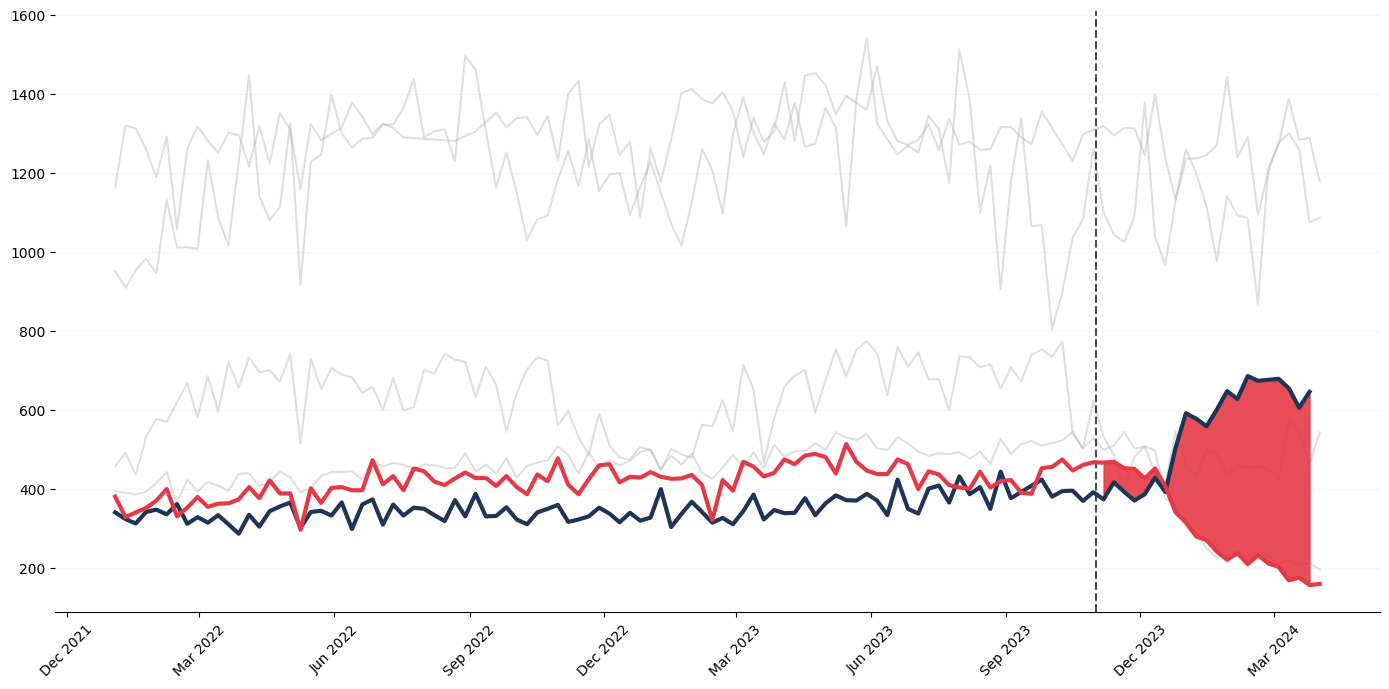

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Load data yang sudah diproses
df_main = pd.read_csv('sources/data_main.csv')
df_main['Week of entry'] = pd.to_datetime(df_main['Week of entry'])

# 2. Setup Figure
fig, ax = plt.subplots(figsize=(14, 7))

# 3. Plot setiap rute pelayaran
passages = df_main['Passage'].unique()

for passage in passages:
    # Filter data per rute
    df_passage = df_main[df_main['Passage'] == passage].sort_values('Week of entry')
    
    # Pengaturan Visual Hierarki untuk kerangka Figma
    if passage == 'Suez':
        # Highlight: Suez (Garis tebal, warna sementara merah)
        ax.plot(df_passage['Week of entry'], df_passage['Number of crossings'], 
                linewidth=3, color='#E63946', label='Terusan Suez')
    elif passage == 'Cape of Good Hope':
        # Highlight: Tanjung Harapan (Garis tebal, warna sementara biru)
        ax.plot(df_passage['Week of entry'], df_passage['Number of crossings'], 
                linewidth=3, color='#1D3557', label='Tanjung Harapan')
    else:
        # Rute lain sebagai latar belakang (Garis tipis, abu-abu)
        ax.plot(df_passage['Week of entry'], df_passage['Number of crossings'], 
                linewidth=1.5, color='#B0B0B0', alpha=0.4)

# 4. Tambahkan garis batas waktu (Eskalasi November 2023)
ax.axvline(pd.to_datetime('2023-11-01'), color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# 5. Bersihkan "Sampah Visual" (Decluttering)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='y', linestyle='-', alpha=0.1)

# Format sumbu X agar lebih rapi (opsional, karena teks ini bisa diganti di Figma)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# 6. Simpan sebagai file .SVG
plt.tight_layout()
plt.savefig('kerangka_visualisasi_kapal.svg', format='svg', transparent=True)
plt.show()

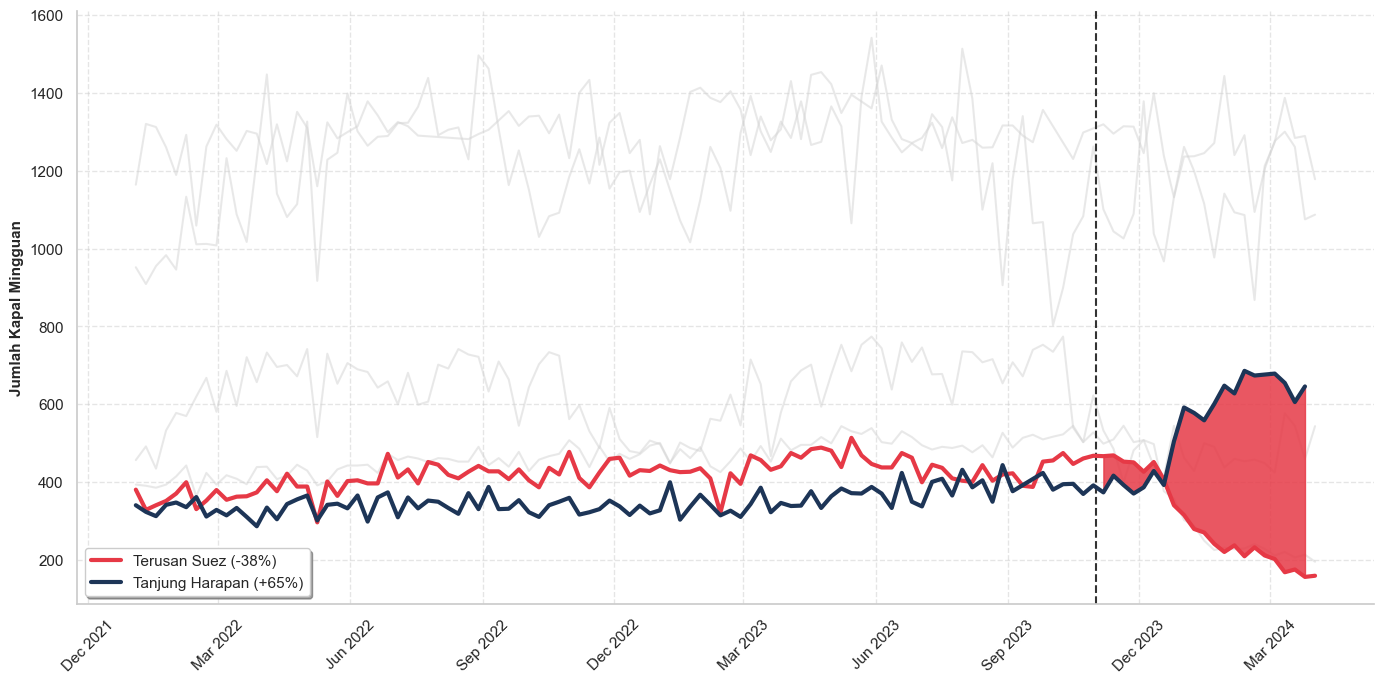

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import matplotlib as mpl

# Biar teks bisa diedit kalau kamu iseng buka di Figma lagi
mpl.rcParams['svg.fonttype'] = 'none'

df_main = pd.read_csv('sources/data_main.csv')
df_main['Week of entry'] = pd.to_datetime(df_main['Week of entry'])

sns.set_theme(style="whitegrid", rc={
    "axes.spines.right": False,
    "axes.spines.top": False,
    "grid.alpha": 0.5,
    "grid.linestyle": "--"
})

fig, ax = plt.subplots(figsize=(14, 7))

df_bg = df_main[~df_main['Passage'].isin(['Suez', 'Cape of Good Hope'])]
df_suez = df_main[df_main['Passage'] == 'Suez']
df_cape = df_main[df_main['Passage'] == 'Cape of Good Hope']


sns.lineplot(data=df_bg, x='Week of entry', y='Number of crossings', 
             hue='Passage', palette=['#D3D3D3']*len(df_bg['Passage'].unique()), 
             linewidth=1.5, alpha=0.5, legend=False, ax=ax, zorder=1)


sns.lineplot(data=df_suez, x='Week of entry', y='Number of crossings', 
             color='#E63946', linewidth=3, label='Terusan Suez (-38%)', ax=ax, zorder=4)
sns.lineplot(data=df_cape, x='Week of entry', y='Number of crossings', 
             color='#1D3557', linewidth=3, label='Tanjung Harapan (+65%)', ax=ax, zorder=4)

conflict_date = pd.to_datetime('2023-11-01')
ax.axvline(conflict_date, color='#333333', linestyle='--', linewidth=1.5, zorder=2)

df_merged = pd.merge(df_suez[['Week of entry', 'Number of crossings']], 
                     df_cape[['Week of entry', 'Number of crossings']], 
                     on='Week of entry', suffixes=('_suez', '_cape'))

df_fill = df_merged[df_merged['Week of entry'] >= conflict_date]

ax.fill_between(df_fill['Week of entry'], 
                df_fill['Number of crossings_suez'], 
                df_fill['Number of crossings_cape'], 
                color='#E63946', alpha=0.85, zorder=3)

mid_date = df_fill['Week of entry'].iloc[len(df_fill) // 2]
mid_y = (df_fill['Number of crossings_suez'].mean() + df_fill['Number of crossings_cape'].mean()) / 2

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.xlabel("")
plt.ylabel("Jumlah Kapal Mingguan", fontsize=11, fontweight='bold')
plt.legend(loc='lower left', frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('kerangka_seaborn_filled.svg', format='svg', transparent=True)
plt.show()

### Visualisasi 2: Bukti Kausal — Volume Ekspor UK & Eskalasi Konflik Gaza

Panel atas menampilkan volume kontainer UK (TEU/bulan) melalui Terusan Suez vs Cape of Good Hope dari data UK Trade Flows. Panel bawah menampilkan jumlah korban bulanan konflik Gaza sebagai bukti pemicu eskalasi. Keduanya berbagi sumbu waktu yang sama untuk memperlihatkan hubungan sebab-akibat secara langsung.

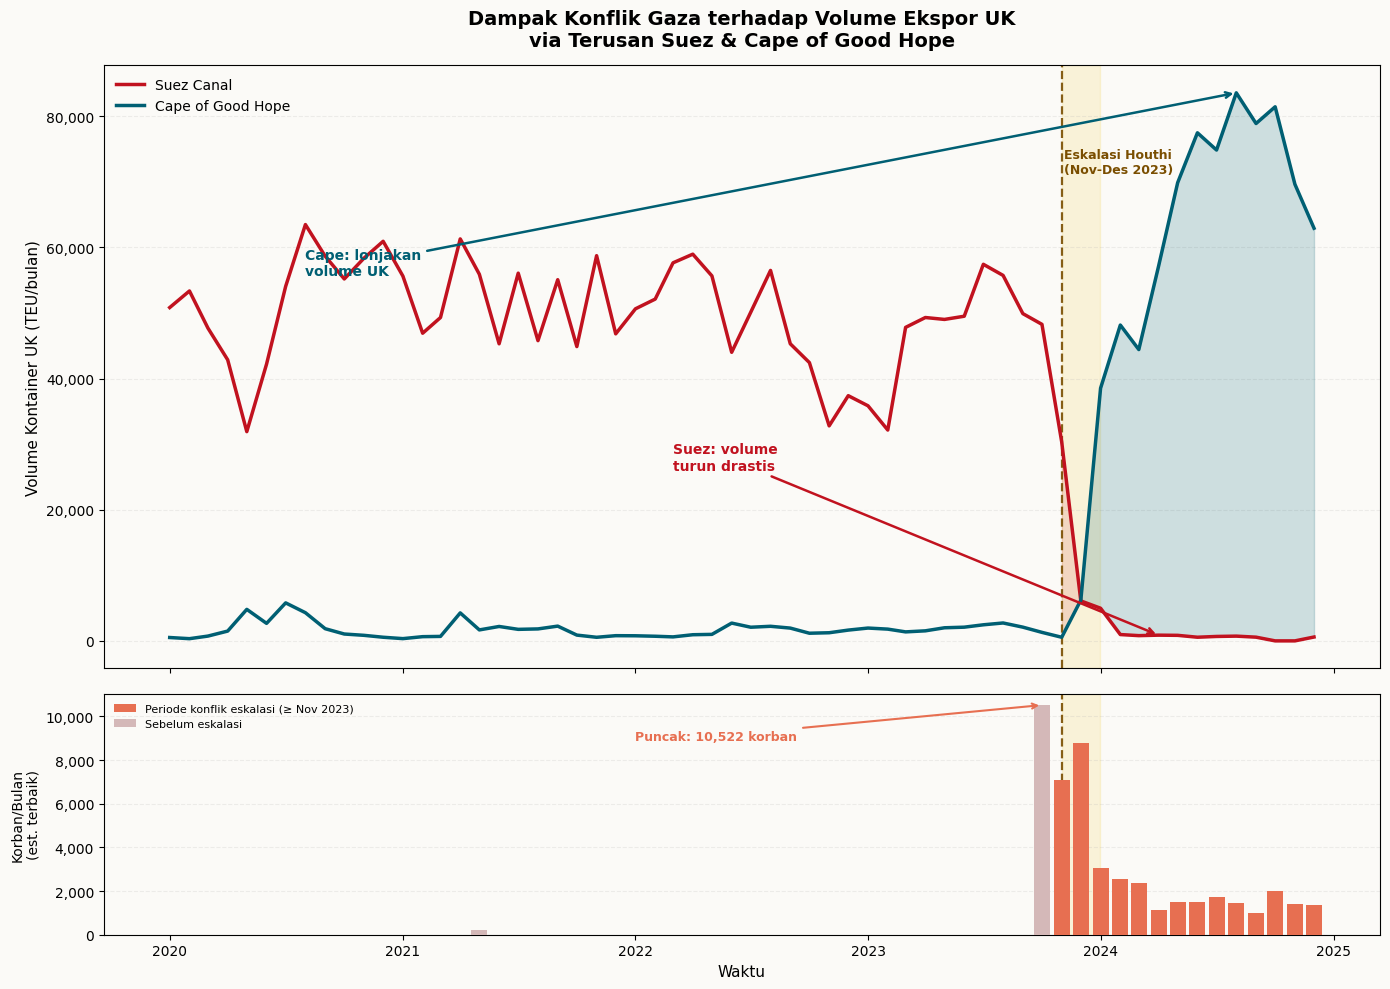

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Load data preprocessed
sec_df = pd.read_csv('sources/data_second.csv')
war_df = pd.read_csv('sources/data_war.csv')

sec_df['Date'] = pd.to_datetime(sec_df['Date'])
war_df['Date'] = pd.to_datetime(war_df['year_month'])

# Isolasi TEU untuk dua rute fokus
teu_suez = sec_df[sec_df['Passage'] == 'Suez'].set_index('Date').sort_index()['TEU']
teu_cape = sec_df[sec_df['Passage'] == 'Cape of Good Hope'].set_index('Date').sort_index()['TEU']

crisis_date = pd.Timestamp('2023-11-01')
COLORS = {
    'Suez': '#c1121f',
    'Cape': '#005f73',
    'war': '#e76f51',
    'pre_war': '#d4b8b8',
}

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 10), sharex=True,
    gridspec_kw={'height_ratios': [2.5, 1]}
)
fig.patch.set_facecolor('#fbfaf7')

# ── Panel atas: Volume TEU ──
ax1.set_facecolor('#fbfaf7')
ax1.plot(teu_suez.index, teu_suez.values,
         color=COLORS['Suez'], linewidth=2.5, label='Suez Canal', zorder=3)
ax1.plot(teu_cape.index, teu_cape.values,
         color=COLORS['Cape'], linewidth=2.5, label='Cape of Good Hope', zorder=3)

# Area selisih TEU setelah krisis
teu_both = pd.DataFrame({'Suez': teu_suez, 'Cape': teu_cape}).dropna()
after = teu_both[teu_both.index >= crisis_date]
ax1.fill_between(after.index, after['Suez'], after['Cape'],
                 where=after['Cape'] >= after['Suez'],
                 color=COLORS['Cape'], alpha=0.18, interpolate=True, zorder=2)
ax1.fill_between(after.index, after['Suez'], after['Cape'],
                 where=after['Suez'] > after['Cape'],
                 color=COLORS['Suez'], alpha=0.12, interpolate=True, zorder=2)

ax1.axvline(crisis_date, color='#7a4e00', linestyle='--', linewidth=1.6, alpha=0.9)
ax1.axvspan(crisis_date, pd.Timestamp('2023-12-31'), color='#f4d35e', alpha=0.2, zorder=0)

ax1.set_title(
    'Dampak Konflik Gaza terhadap Volume Ekspor UK\nvia Terusan Suez & Cape of Good Hope',
    fontsize=14, weight='bold', pad=14)
ax1.set_ylabel('Volume Kontainer UK (TEU/bulan)', fontsize=11)
ax1.legend(frameon=False, loc='upper left')
ax1.grid(axis='y', linestyle='--', alpha=0.2)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Anotasi callout editorial
suez_baseline = float(teu_suez.loc['2023-01':'2023-10'].mean())
cape_max = float(teu_cape.max())
cape_post_mean = float(teu_cape.loc['2024-01':'2024-12'].mean())

ax1.annotate(
    'Suez: volume\nturun drastis',
    xy=(pd.Timestamp('2024-04-01'), float(teu_suez.loc[pd.Timestamp('2024-04-01')])),
    xytext=(pd.Timestamp('2022-03-01'), suez_baseline * 0.55),
    arrowprops=dict(arrowstyle='->', color=COLORS['Suez'], lw=1.8),
    fontsize=10, color=COLORS['Suez'], weight='bold'
)
ax1.annotate(
    'Cape: lonjakan\nvolume UK',
    xy=(pd.Timestamp('2024-08-01'), float(teu_cape.loc[pd.Timestamp('2024-08-01')])),
    xytext=(pd.Timestamp('2020-08-01'), cape_post_mean * 0.85),
    arrowprops=dict(arrowstyle='->', color=COLORS['Cape'], lw=1.8),
    fontsize=10, color=COLORS['Cape'], weight='bold'
)
ax1.text(
    pd.Timestamp('2023-11-05'), cape_max * 0.9,
    'Eskalasi Houthi\n(Nov-Des 2023)',
    fontsize=9, color='#7a4e00', weight='bold', va='top'
)

# ── Panel bawah: Korban konflik Gaza ──
ax2.set_facecolor('#fbfaf7')

bar_colors = [
    COLORS['war'] if d >= crisis_date else COLORS['pre_war']
    for d in war_df['Date']
]
ax2.bar(war_df['Date'], war_df['best'], width=25, color=bar_colors, zorder=3)
ax2.axvline(crisis_date, color='#7a4e00', linestyle='--', linewidth=1.6, alpha=0.9)
ax2.axvspan(crisis_date, pd.Timestamp('2023-12-31'), color='#f4d35e', alpha=0.2, zorder=0)

ax2.set_ylabel('Korban/Bulan\n(est. terbaik)', fontsize=10)
ax2.set_xlabel('Waktu', fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.2)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Label konflik eskalasi pada bar chart
peak_month = war_df.loc[war_df['best'].idxmax(), 'Date']
peak_val = war_df['best'].max()
ax2.annotate(
    f"Puncak: {peak_val:,.0f} korban",
    xy=(peak_month, peak_val),
    xytext=(pd.Timestamp('2022-01-01'), peak_val * 0.85),
    arrowprops=dict(arrowstyle='->', color=COLORS['war'], lw=1.5),
    fontsize=9, color=COLORS['war'], weight='bold'
)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['war'], label='Periode konflik eskalasi (≥ Nov 2023)'),
    Patch(facecolor=COLORS['pre_war'], label='Sebelum eskalasi'),
]
ax2.legend(handles=legend_elements, frameon=False, fontsize=8, loc='upper left')

plt.tight_layout()
plt.subplots_adjust(hspace=0.06)
plt.show()